In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
# Load dataset
df = pd.read_csv("Social_Network_Ads.csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [8]:
# Gender distribution (before encoding)
gender_counts = df['Gender'].value_counts()

print("\nGender Distribution:")
print(gender_counts)


Gender Distribution:
Gender
Female    204
Male      196
Name: count, dtype: int64


In [9]:
# Encode categorical data (Gender)

# Convert Male/Female → 1/0
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Feature selection
X = df[['Gender', 'Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

# Metrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = (FP + FN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

# Output Results
print("\nConfusion Matrix:\n", cm)
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[65  3]
 [ 7 25]]
TP: 25
TN: 65
FP: 3
FN: 7
Accuracy: 0.9
Error Rate: 0.1
Precision: 0.8928571428571429
Recall: 0.78125

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93        68
           1       0.89      0.78      0.83        32

    accuracy                           0.90       100
   macro avg       0.90      0.87      0.88       100
weighted avg       0.90      0.90      0.90       100



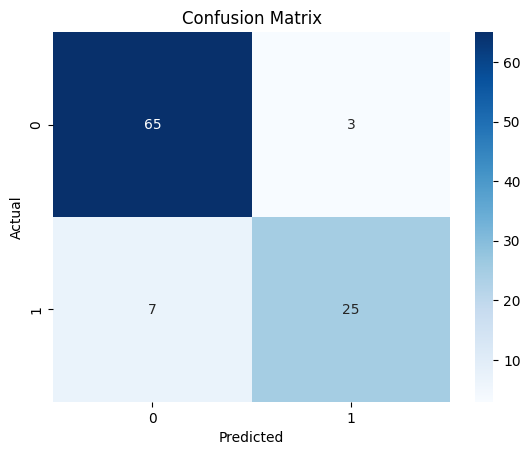

In [10]:
# Visualization (Confusion Matrix)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()